# We can test the performance on the simulated data

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
from scipy.optimize import minimize
from scipy.stats import norm
import celerite2
from celerite2 import terms
from prettytable import PrettyTable
import sys
from pathlib import Path
from IPython.display import display as ipy_display

sys.path.append(str(Path('../..').resolve()))
from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

#---GP Helpers---

def set_params(log_params, k, gp):
    params = np.exp(log_params)
    gp.kernel = terms.SHOTerm(sigma=params[0], rho=params[k], Q=params[2*k])
    for i in range(1, k):
        gp.kernel += terms.SHOTerm(sigma=params[i], rho=params[k+i], Q=params[2*k+i])
    return gp

def NLL(log_params, gp, k, y):
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

def lnPost_gp(log_params, gp, k, y, initial_guesses, bounds, prior_std=3):
    if np.any(log_params < bounds[:, 0]) or np.any(log_params > bounds[:, 1]):
        return -np.inf
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    lnL = gp.log_likelihood(y)
    if not np.isfinite(lnL):
        return -np.inf
    return lnL - 0.5 * np.sum(((np.exp(log_params) - np.exp(initial_guesses)) / prior_std) ** 2)

#---Data Helpers---

def downsample_min_gap(df, minimum_gap):
    days = df['day'].values
    keep = np.zeros(len(days), dtype=bool)
    keep[0] = True
    last = days[0]
    for i in range(1, len(days)):
        if days[i] - last >= minimum_gap:
            keep[i] = True
            last = days[i]
    return df[keep].reset_index(drop=True)

def check_constant(predictions, MAD, tol=2, percentile=84):
    amps = predictions.max(axis=1) - predictions.min(axis=1)
    return np.percentile(amps, percentile) / MAD < tol

def gaussian_smooth(t, y, sigma, n_eval=1000):
    t_eval = np.linspace(t.min(), t.max(), n_eval)
    w = np.exp(-0.5 * ((t[:, None] - t_eval[None, :]) / sigma) ** 2)
    return t_eval, (w * y[:, None]).sum(axis=0) / w.sum(axis=0)

#---Fourier Ground Truth---

def fit_Fourier(raw_data_df, MAD, med_ref, rho_priors, test_df,
                error_percent, n_walkers, subsample=500):
    '''Returns model_preds, mean_pred, lb, ub, t_plot_year'''
    fourier_df = raw_data_df[(raw_data_df['sind'] - med_ref).abs() < MAD].reset_index(drop=True)
    raw_std = np.std(fourier_df['sind'])

    log_AB_bounds = np.log([[1e-4, 5*raw_std] for _ in range(6)])
    log_T_bounds = np.log([[1e-4, raw_data_df['day'].iloc[-1] - raw_data_df['day'].iloc[0]]])
    c_bounds = [[fourier_df['sind'].min(), fourier_df['sind'].max()]]
    bounds = np.concatenate([log_AB_bounds, log_T_bounds, c_bounds])

    t0_ref_day = raw_data_df['day'].iloc[0]
    t0_ref_year = raw_data_df['year'].iloc[0]
    def to_year(day): return t0_ref_year + (day - t0_ref_day) / 365.25

    def lnPost_Fourier(params, t, y, sigma, weights, bounds):
        if np.any(params < bounds[:, 0]) or np.any(params > bounds[:, 1]):
            return -np.inf
        A1, A2, A3 = np.exp(params[0:3])
        B1, B2, B3 = np.exp(params[3:6])
        T = np.exp(params[6]); c = params[7]
        model = c + A1*np.sin(2*np.pi*t/T) + B1*np.cos(2*np.pi*t/T)
        model += A2*np.sin(4*np.pi*t/T) + B2*np.cos(4*np.pi*t/T)
        model += A3*np.sin(6*np.pi*t/T) + B3*np.cos(6*np.pi*t/T)
        return np.sum(weights * (-np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*((y - model)/sigma)**2))

    ig_AB = [(fourier_df['sind'].max() - fourier_df['sind'].min()) / 6] * 6
    ig = np.concatenate([np.log(ig_AB), np.log([rho_priors['mid']]), [np.median(fourier_df['sind'])]])
    wsc = ig + 1e-4 * np.random.randn(n_walkers, len(ig))

    tau = rho_priors['mid']
    t0_day = test_df['day'].iloc[0]
    t_arr = fourier_df['day'].to_numpy()
    y_arr = fourier_df['sind'].to_numpy()
    sigma = y_arr * error_percent / 100
    weights = np.where(t_arr < t0_day, np.exp(-(t0_day - t_arr) / tau), 1.0)

    sampler = emcee.EnsembleSampler(n_walkers, len(ig), lnPost_Fourier,
                                    args=(t_arr, y_arr, sigma, weights, bounds))
    sampler.run_mcmc(wsc, nsteps=10000, progress=False)
    flat = sampler.get_chain(discard=5000, flat=True)

    t_plot = np.linspace(raw_data_df['day'].min(), raw_data_df['day'].max(), 2000)
    t_plot_year = to_year(t_plot)
    step = max(1, len(flat) // subsample)
    model_preds = []
    for s in flat[::step]:
        A1, A2, A3 = np.exp(s[0:3]); B1, B2, B3 = np.exp(s[3:6])
        T = np.exp(s[6]); c = s[7]
        m = c + A1*np.sin(2*np.pi*t_plot/T) + B1*np.cos(2*np.pi*t_plot/T)
        m += A2*np.sin(4*np.pi*t_plot/T) + B2*np.cos(4*np.pi*t_plot/T)
        m += A3*np.sin(6*np.pi*t_plot/T) + B3*np.cos(6*np.pi*t_plot/T)
        model_preds.append(m)
    model_preds = np.array(model_preds)
    return model_preds, model_preds.mean(0), np.percentile(model_preds, 16, 0), np.percentile(model_preds, 84, 0), t_plot_year

def truth_in_x(model_preds, t_plot_year, t0_year, lookahead_years):
    '''Returns (median_min_year, (lb_year, ub_year)) at 16th/84th percentiles.'''
    mask = (t_plot_year >= t0_year) & (t_plot_year <= t0_year + lookahead_years)
    window_preds = model_preds[:, mask]
    window_t = t_plot_year[mask]
    min_years = window_t[np.argmin(window_preds, axis=1)]
    lb, ub = np.percentile(min_years, [16, 84])
    return float(np.median(min_years)), (float(lb), float(ub))

def run_star(datapath, star_name, star_type='G', add_prefix=False,
             error_percent=2.5, sigma_upper_mult=5.0, q_bounds_in=(1, 5),
             n_target_windows=5, min_gap=3, n_walkers=32,
             total_sample_count=2500, subsample=500, SEED=1701,
             pred_forward_years=2, low_cad=30, high_cad=10,
             direct_bound_tol=0.1, sm2016_bound_tol=0.2, mean_bound_tol=1,
             require_mid=True, valid_metric='CRPS', verbose=False):
    '''
    Run the full GPR + Fourier ground truth pipeline on one star.
    Returns a nested dict; flatten with results_to_df().

    Return schema:
        {star, n_obs, span_years, skipped, skip_reason,
         splits: [{best_combo, valid_metric_value, rho_mid_years, Q_mid,
                   n_cycles_obs, is_const, aleatoric_frac_at_t0,
                   windows: [{lookahead_years, t0_year,
                              gpr_med, gpr_lb68, gpr_ub68, gpr_lb95, gpr_ub95,
                              truth_med, truth_lb, truth_ub,
                              error, abs_error, in_68, in_95,
                              gpr_width_68, truth_width}]}]}
    '''
    np.random.seed(SEED)

    #---Data Loading---
    try:
        raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)
        data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=True)
    except Exception as e:
        return {'star': star_name, 'skipped': True, 'skip_reason': f'load error: {e}', 'splits': []}

    n_obs = len(data_df)
    if n_obs < 100:
        return {'star': star_name, 'n_obs': n_obs, 'skipped': True,
                'skip_reason': 'fewer than 100 observations', 'splits': []}

    span = data_df['year'].iloc[-1] - data_df['year'].iloc[0]
    if span < 1:
        return {'star': star_name, 'n_obs': n_obs, 'span_years': span,
                'skipped': True, 'skip_reason': 'span < 1 year', 'splits': []}

    data_df = downsample_min_gap(data_df, min_gap)

    #---Build Windows---
    n_win = n_target_windows
    divide_train_splits = [(0.75 / n_win) * n for n in range(1, n_win + 1)]
    span_train_split = (
        (data_df['year'] < data_df['year'].iloc[0] + 0.15 * span).sum() / len(data_df)
    )
    raw_train_splits = np.maximum(divide_train_splits, span_train_split)
    train_splits = np.unique(raw_train_splits)
    train_idxs = np.round(len(data_df) * train_splits).astype(int)

    span_valid_splits = np.array([
        (data_df['year'] < data_df['year'].iloc[idx] + 0.2 * span).sum() / len(data_df) - ts
        for idx, ts in zip(train_idxs, train_splits)
    ])
    valid_splits = np.maximum(0.1, span_valid_splits)

    retraining_split = train_splits + valid_splits
    mask = retraining_split < 1
    train_splits = train_splits[mask]
    valid_splits = valid_splits[mask]
    train_idxs = train_idxs[mask]
    retraining_split = retraining_split[mask]

    retraining_idxs = np.round(len(data_df) * retraining_split).astype(int)
    mask_ib = retraining_idxs < len(data_df)
    train_splits = train_splits[mask_ib]
    valid_splits = valid_splits[mask_ib]
    retraining_idxs = retraining_idxs[mask_ib]

    if len(train_splits) < 1:
        test_split = (data_df['year'] >= data_df['year'].iloc[-1] - 1).sum() / len(data_df)
        remaining = 1 - test_split
        retrain_end_idx = int(np.round(len(data_df) * remaining)) - 1
        if data_df['year'].iloc[retrain_end_idx] - data_df['year'].iloc[0] < 1:
            return {'star': star_name, 'n_obs': len(data_df), 'span_years': span,
                    'skipped': True, 'skip_reason': 'combined train+valid span < 1 year', 'splits': []}
        train_splits = np.array([remaining / 2])
        valid_splits = np.array([remaining / 2])
        retraining_idxs = np.round(len(data_df) * (train_splits + valid_splits)).astype(int)

    test_t0s = data_df['year'].iloc[retraining_idxs - 1].to_numpy()
    test_spans = data_df['year'].iloc[-1] - test_t0s
    test_window_lenss = [
        np.cumsum(np.ones(max(0, int(np.floor(ts))), dtype=int))
        for ts in test_spans
    ]

    #---Model Selection---
    prior_combos = {
        '1m':   {'k': 1, 'q_priors': None, 'cycle_keys': ['mid']},
        '2sm':  {'k': 2, 'q_priors': None, 'cycle_keys': ['short', 'mid']},
        '2ml':  {'k': 2, 'q_priors': None, 'cycle_keys': ['mid',   'long']},
        '3sml': {'k': 3, 'q_priors': None, 'cycle_keys': ['short', 'mid', 'long']},
    }
    if require_mid:
        prior_combos = {nm: v for nm, v in prior_combos.items() if 'mid' in v['cycle_keys']}

    split_results = []

    for train_split, valid_split, test_window_lens in zip(
            train_splits, valid_splits, test_window_lenss):

        try:
            #---Rebuild Window Splits---
            dirty_train_df, dirty_valid_df, test_df = split_df(
                data_df, train_split=train_split, valid_split=valid_split)
            train_df, valid_df, MAD = clean_df(
                dirty_train_df, dirty_valid_df, tol=4, verbose=False, plot=False)

            #---Find prior on training set---
            classified_signal_data = find_classify_signals(
                dirty_train_df,
                plot_fitpeaks=False, verbose_fitpeaks=False,
                plot_genpriors=False, verbose_genpriors=False)
            rho_priors, rho_prior_bounds, _ = get_priors(
                classified_signal_data, star_type=star_type,
                direct_bound_tol=direct_bound_tol,
                sm2016_bound_tol=sm2016_bound_tol,
                mean_bound_tol=mean_bound_tol,
                verbose=False)

            #---Compare each combination---
            train_yerr = train_df['sind'] * error_percent / 100
            train_mean = train_df['sind'].mean()
            train_std = train_df['sind'].std()

            combo_results = {}
            for combo_name, combo_info in prior_combos.items():
                k_c = combo_info['k']
                q_prior_type = combo_info['q_priors']
                cycle_keys_c = combo_info['cycle_keys']

                np.random.seed(SEED)
                q_0s = ([np.random.uniform(0, 0.5) for _ in range(k_c)]
                        if q_prior_type == 'overdamped'
                        else [np.random.uniform(0.5, 1) for _ in range(k_c)])
                sigma_0s = [train_std / k_c for _ in range(k_c)]
                rho_0s = [rho_priors[ck] for ck in cycle_keys_c]

                ig_raw = np.concatenate([sigma_0s, rho_0s, q_0s])
                q_bnd = ([(- np.inf, np.log(0.5)) for _ in range(k_c)]
                         if q_prior_type == 'overdamped'
                         else [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1]))
                               for _ in range(k_c)])
                sigma_bnd = [(np.log(1e-4), np.log(train_std * sigma_upper_mult))
                             for _ in range(k_c)]
                rho_bnd = np.log([rho_prior_bounds[ck] for ck in cycle_keys_c])
                bounds_c = np.concatenate([sigma_bnd, rho_bnd, q_bnd])

                perturbs = ig_raw * 0.1 * np.random.normal(size=(25, len(ig_raw)))
                perturbed = np.log(np.clip(ig_raw + perturbs, 1e-6, None))

                best_NLL, best_res_c = np.inf, None
                for ig in perturbed:
                    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
                    for ki in range(1, k_c):
                        kernel += terms.SHOTerm(sigma=sigma_0s[ki], rho=rho_0s[ki], Q=q_0s[ki])
                    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
                    gp.compute(train_df['day'], yerr=train_yerr)
                    res = minimize(NLL, ig, args=(gp, k_c, train_df['sind'].to_numpy()),
                                   method='L-BFGS-B', bounds=bounds_c)
                    if res.fun < best_NLL:
                        best_NLL, best_res_c = res.fun, res

                gp = set_params(best_res_c.x, k_c, gp)
                gp.recompute()
                bp = np.exp(best_res_c.x)

                mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
                y_valid = valid_df['sind'].to_numpy()
                valid_yerr = valid_df['sind'] * error_percent / 100
                total_var = cov + valid_yerr ** 2
                total_std = np.sqrt(total_var)

                nlpd = (0.5 * np.log(2 * np.pi * total_var)
                        + (y_valid - mu) ** 2 / (2 * total_var)).mean()
                z = (y_valid - mu) / total_std
                crps = (total_std * (z * (2 * norm.cdf(z) - 1)
                        + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))).mean()

                combo_results[combo_name] = {
                    'NLPD': nlpd, 'CRPS': crps,
                    'params': bp, 'bounds': bounds_c,
                }

            #---Select best model---
            best_metric, best_combo_name = np.inf, None
            for cname, cr in combo_results.items():
                if cr[valid_metric] < best_metric:
                    best_metric, best_combo_name = cr[valid_metric], cname
                    best_params = cr['params']
                    best_bounds = cr['bounds']

            if verbose:
                print(f"{star_name}: selected {best_combo_name} ({valid_metric}={best_metric:.4f})")

            #---Retrain on train+valid---
            retrain_df = downsample_min_gap(pd.concat([train_df, valid_df]), min_gap)
            combo_info = prior_combos[best_combo_name]
            k = combo_info['k']
            cycle_keys = combo_info['cycle_keys']

            retrain_yerr = retrain_df['sind'] * error_percent / 100
            retrain_mean = retrain_df['sind'].mean()

            p0 = best_params
            kernel = terms.SHOTerm(sigma=p0[0], rho=p0[k], Q=p0[2*k])
            for ki in range(1, k):
                kernel += terms.SHOTerm(sigma=p0[ki], rho=p0[k + ki], Q=p0[2*k + ki])

            gp_retrain = celerite2.GaussianProcess(kernel, mean=retrain_mean)
            gp_retrain.compute(retrain_df['day'], yerr=retrain_yerr)

            retrain_res = minimize(NLL, np.log(best_params),
                                   args=(gp_retrain, k, retrain_df['sind'].to_numpy()),
                                   method='L-BFGS-B', bounds=best_bounds)
            gp_retrain = set_params(retrain_res.x, k, gp_retrain)
            gp_retrain.recompute()
            retrain_params = np.exp(retrain_res.x)

            #---MCMC posterior---
            np.random.seed(SEED)
            y = retrain_df['sind'].to_numpy()
            wsc = np.log(retrain_params) + 1e-5 * np.random.randn(n_walkers, len(retrain_params))

            sampler = emcee.EnsembleSampler(
                n_walkers, len(retrain_params), lnPost_gp,
                args=(gp_retrain, k, y, retrain_res.x, best_bounds))
            sampler.run_mcmc(wsc, nsteps=total_sample_count, progress=False)

            ln_chains = sampler.get_chain(discard=1000)
            ln_samples = ln_chains.reshape(-1, ln_chains.shape[-1])
            np.random.seed(SEED)
            sel = np.random.choice(len(ln_samples), size=subsample, replace=False)
            ln_samples = ln_samples[sel]

            #---Forecast grid---
            t0_day = retrain_df['day'].iloc[0]
            t0_year = retrain_df['year'].iloc[0]

            t_pred_start = retrain_df['day'].iloc[-1]
            t_pred_start_year = retrain_df['year'].iloc[-1]
            t_ring_end = t_pred_start + 365
            t_pred_end = max(t_pred_start + 365 * pred_forward_years,
                             test_df['day'].iloc[-1])

            sampled_days = np.concatenate([
                np.arange(t_pred_start - 365 * 0.5, t_ring_end, low_cad),
                np.arange(t_ring_end, t_pred_end, high_cad),
            ])
            sampled_years = t0_year + (sampled_days - t0_day) / 365.25

            preds, pred_vars = [], []
            for ln_s in ln_samples:
                set_params(ln_s, k, gp_retrain)
                gp_retrain.recompute(quiet=True)
                p, pv = gp_retrain.predict(retrain_df['sind'], t=sampled_days, return_var=True)
                preds.append(p); pred_vars.append(pv)

            preds = np.array(preds)
            pred_vars = np.array(pred_vars)
            aleatoric = pred_vars.mean(axis=0)
            epistemic = preds.var(axis=0)
            is_const = check_constant(preds, MAD)

            #---Fourier ground truth---
            fourier_preds, _, _, _, fourier_t_year = fit_Fourier(
                raw_data_df=data_df, MAD=MAD,
                med_ref=dirty_train_df['sind'].median(),
                rho_priors=rho_priors, test_df=test_df,
                error_percent=error_percent, n_walkers=n_walkers,
            )

            # Append full-span window
            test_window_lens = np.append(
                test_window_lens, data_df['year'].iloc[-1] - t_pred_start_year)

            #---Split-level diagnostics---
            t0_idx = np.searchsorted(sampled_years, t_pred_start_year)
            ale_t0 = float(aleatoric[t0_idx]) if t0_idx < len(aleatoric) else np.nan
            epi_t0 = float(epistemic[t0_idx]) if t0_idx < len(epistemic) else np.nan
            tot_var_t0 = ale_t0 + epi_t0
            aleatoric_frac = ale_t0 / tot_var_t0 if tot_var_t0 > 0 else np.nan

            mid_idx = cycle_keys.index('mid')
            rho_mid_days = retrain_params[k + mid_idx]
            rho_mid_years = rho_mid_days / 365.25
            Q_mid = retrain_params[2*k + mid_idx]
            n_cycles_obs = span / rho_mid_years

            #---Per-window statistics---
            windows = []
            for w_len in test_window_lens:
                t_end_w = t_pred_start_year + float(w_len)
                w_mask = (sampled_years >= t_pred_start_year) & (sampled_years <= t_end_w)

                if not w_mask.any():
                    windows.append({
                        'lookahead_years': float(w_len),
                        't0_year': float(t_pred_start_year),
                        **{kk: np.nan for kk in [
                            'gpr_med', 'gpr_lb68', 'gpr_ub68', 'gpr_lb95', 'gpr_ub95',
                            'truth_med', 'truth_lb', 'truth_ub',
                            'error', 'abs_error', 'gpr_width_68', 'truth_width',
                        ]},
                        'in_68': False, 'in_95': False,
                    })
                    continue

                w_preds = preds[:, w_mask]
                w_years = sampled_years[w_mask]
                gpr_min_years = w_years[np.argmin(w_preds, axis=1)]
                gpr_med = float(np.median(gpr_min_years))
                p2_5, p16, p84, p97_5 = np.percentile(gpr_min_years, [2.5, 16, 84, 97.5])

                try:
                    truth_med, (truth_lb, truth_ub) = truth_in_x(
                        fourier_preds, fourier_t_year, t_pred_start_year, float(w_len))
                except Exception:
                    truth_med = truth_lb = truth_ub = np.nan

                error = gpr_med - truth_med if not np.isnan(truth_med) else np.nan
                windows.append({
                    'lookahead_years': float(w_len),
                    't0_year': float(t_pred_start_year),
                    'gpr_med': gpr_med,
                    'gpr_lb68': float(p16),
                    'gpr_ub68': float(p84),
                    'gpr_lb95': float(p2_5),
                    'gpr_ub95': float(p97_5),
                    'truth_med': float(truth_med) if not np.isnan(truth_med) else np.nan,
                    'truth_lb': float(truth_lb) if not np.isnan(truth_lb) else np.nan,
                    'truth_ub': float(truth_ub) if not np.isnan(truth_ub) else np.nan,
                    'error': float(error) if not np.isnan(error) else np.nan,
                    'abs_error': float(abs(error)) if not np.isnan(error) else np.nan,
                    'in_68': bool(p16 <= truth_med <= p84) if not np.isnan(truth_med) else False,
                    'in_95': bool(p2_5 <= truth_med <= p97_5) if not np.isnan(truth_med) else False,
                    'gpr_width_68': float(p84 - p16),
                    'truth_width': float(truth_ub - truth_lb) if not np.isnan(truth_ub) else np.nan,
                })

            split_results.append({
                'best_combo': best_combo_name,
                'valid_metric_value': float(best_metric),
                'rho_mid_years': float(rho_mid_years),
                'Q_mid': float(Q_mid),
                'n_cycles_obs': float(n_cycles_obs),
                'is_const': bool(is_const),
                'aleatoric_frac_at_t0': float(aleatoric_frac) if not np.isnan(aleatoric_frac) else np.nan,
                'windows': windows,
            })

        except Exception as e:
            if verbose:
                print(f"{star_name}: split error ({e})")
            continue

    return {
        'star': star_name,
        'n_obs': len(data_df),
        'span_years': float(span),
        'skipped': False,
        'skip_reason': None,
        'splits': split_results,
    }

In [11]:
def results_to_df(results_list):
    rows = []
    for r in results_list:
        if r.get('skipped', False):
            continue
        for split_idx, split in enumerate(r['splits']):
            base = {
                'star': r['star'],
                'n_obs': r['n_obs'],
                'span_years': r['span_years'],
                'split_idx': split_idx,
                'best_combo': split['best_combo'],
                'rho_mid_years': split['rho_mid_years'],
                'Q_mid': split['Q_mid'],
                'n_cycles_obs': split['n_cycles_obs'],
                'is_const': split['is_const'],
                'aleatoric_frac_at_t0': split['aleatoric_frac_at_t0'],
                'valid_metric_value': split['valid_metric_value'],
            }
            for win in split['windows']:
                rows.append({**base, **win})
    return pd.DataFrame(rows)


In [ ]:
from pathlib import Path
import numpy as np

sim_root = Path('../../Data/simulated')
params = np.load(sim_root / 'star_params.npz', allow_pickle=True)

star_labels = params['labels']

def _prior_type(stype):
    return stype[0]  # ME->M, MM->M, else unchanged

# Same 3 G-type stars across all folders for consistency
g_indices = np.where(star_labels == 'G')[0][:3]

# Discover folders in sorted order by numeric rate
rate_folders = sorted(
    [f for f in sim_root.iterdir() if f.is_dir()],
    key=lambda f: float(f.name.rstrip('d'))
)

dfs_by_rate = {}   # {sampling_rate_str: df_sim}

for folder in rate_folders:
    rate_str = folder.name          # e.g. '1.0d'
    rate_days = float(rate_str.rstrip('d'))
    print(f"\n=== Sampling rate: {rate_str} ===")

    results = []
    for i in g_indices:
        stype = star_labels[i]
        fpath = folder / f'sim{i:04d}_{stype}_caii.txt'
        star_name = f'sim{i:04d}_{stype}'
        print(f'  {star_name}  (P_cyc={params["P_cycs"][i]:.1f} yr, P_rot={params["P_rots"][i]:.1f} d)')
        result = run_star(
            datapath=str(fpath),
            star_name=star_name,
            star_type=_prior_type(stype),
            add_prefix=False,
            n_target_windows=5,
            verbose=True,
        )
        results.append(result)

    df = results_to_df(results)
    df['sampling_rate_days'] = rate_days
    dfs_by_rate[rate_str] = df

df_sim_all = pd.concat(dfs_by_rate.values(), ignore_index=True)
print(f"\nDone. {len(dfs_by_rate)} sampling rates, {len(df_sim_all)} total rows.")




=== Sampling rate: 1.0d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
sim0041_G: selected 2sm (CRPS=7.1398)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0041_G: selected 3sml (CRPS=7.6644)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0041_G: selected 3sml (CRPS=7.5807)


...

c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0053_G: selected 3sml (CRPS=2.5570)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



=== Sampling rate: 60.3d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
  sim0046_G  (P_cyc=10.7 yr, P_rot=6.9 d)
  sim0053_G  (P_cyc=8.2 yr, P_rot=15.8 d)

=== Sampling rate: 70.2d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
  sim0046_G  (P_cyc=10.7 yr, P_rot=6.9 d)
  sim0053_G  (P_cyc=8.2 yr, P_rot=15.8 d)

=== Sampling rate: 80.1d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
  sim0046_G  (P_cyc=10.7 yr, P_rot=6.9 d)
  sim0053_G  (P_cyc=8.2 yr, P_rot=15.8 d)

=== Sampling rate: 90.0d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
  sim0046_G  (P_cyc=10.7 yr, P_rot=6.9 d)
  sim0053_G  (P_cyc=8.2 yr, P_rot=15.8 d)

Done. 10 sampling rates, 981 total rows.


,star,n_obs,span_years,split_idx,best_combo,rho_mid_years,Q_mid,n_cycles_obs,is_const,aleatoric_frac_at_t0,...,truth_med,truth_lb,truth_ub,error,abs_error,in_68,in_95,gpr_width_68,truth_width,sampling_rate_days
0,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.073406,1994.073406,1994.073406,0.007863,0.007863,False,False,0.000000,0.000000,1.0
1,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
2,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
3,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
4,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0


In [24]:
df_sim_all.to_csv("df_sim_all_test.csv")

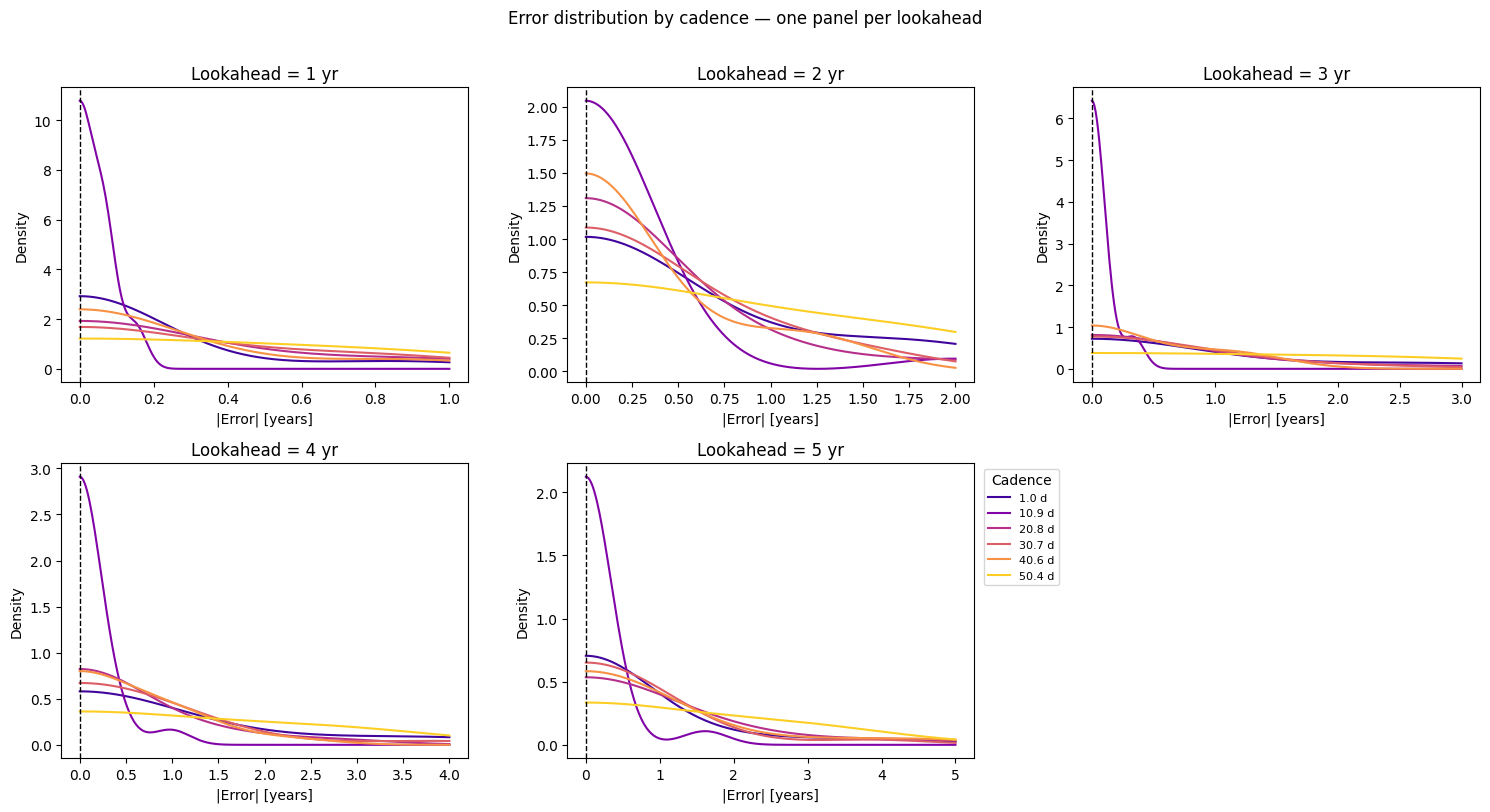

In [25]:
df = df_sim_all

from scipy.stats import gaussian_kde

integer_lookaheads = sorted(
    df[(df['lookahead_years'] % 1 == 0) & (df['lookahead_years'] <= 5)]['lookahead_years'].unique()
)
sampling_rates_sorted = sorted(df['sampling_rate_days'].unique())

n_la = len(integer_lookaheads)
ncols = 3
nrows = int(np.ceil(n_la / ncols))

rate_colors = {r: c for r, c in zip(
    sampling_rates_sorted,
    plt.cm.plasma(np.linspace(0.1, 0.9, len(sampling_rates_sorted)))
)}

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = axes.flatten()

for ax_idx, la in enumerate(integer_lookaheads):
    ax = axes[ax_idx]
    for rate in sampling_rates_sorted:
        d = df[(df['lookahead_years'] == la) & (df['sampling_rate_days'] == rate)]['error'].dropna()
        if len(d) < 3:
            continue
        xs = np.linspace(0, la, 300)
        kde_vals = gaussian_kde(d)(xs) + gaussian_kde(d)(-xs)
        kde_vals /= np.trapezoid(kde_vals, xs)
        ax.plot(xs, kde_vals, color=rate_colors[rate], lw=1.5, label=f'{rate:.1f} d')

    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_title(f'Lookahead = {int(la)} yr')
    ax.set_xlabel('|Error| [years]')
    ax.set_ylabel('Density')

for ax in axes[n_la:]:
    ax.set_visible(False)

axes[n_la - 1].legend(
    title='Cadence', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8
)

fig.suptitle('Error distribution by cadence — one panel per lookahead', y=1.01)
fig.tight_layout()
plt.show()
